In [7]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

import shap
import lime
import lime.lime_tabular

# ============================================
# STEP 1: Load Dataset
# ============================================

print("\n1. Loading Titanic dataset...")
df = pd.read_csv("titanic_dataset.csv")

# ============================================
# STEP 2: Features
# ============================================

raw_categorical_features = ["Sex", "Embarked"]
raw_numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

target = "Survived"

# ============================================
# STEP 3: Handle Missing Values
# ============================================

for col in raw_categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in raw_numeric_features:
    df[col] = df[col].fillna(df[col].median())

# ============================================
# STEP 4: Pipeline
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), raw_categorical_features),
        ("num", StandardScaler(), raw_numeric_features),
    ]
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    ))
])

# ============================================
# STEP 5: Train/Test Split
# ============================================

X = df[raw_categorical_features + raw_numeric_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================
# STEP 6: Train
# ============================================

print("\n2. Training XGBoost model...")
pipeline.fit(X_train, y_train)

accuracy = pipeline.score(X_test, y_test)
print("Accuracy:", accuracy)

# ============================================
# STEP 7: RAW Prediction
# ============================================

# ============================================
# STEP 8: Save Model
# ============================================

joblib.dump(pipeline, "titanic_xgb_pipeline.pkl")
print("\nModel saved!")

# ============================================
# STEP 9: SHAP (BEST for XGBoost)
# ============================================

print("\n3. SHAP explanation...")

try:
    preprocessor = pipeline.named_steps["preprocessing"]
    model = pipeline.named_steps["model"]

    X_sample = X_train.sample(100)
    X_processed = preprocessor.transform(X_sample)

    if hasattr(X_processed, "toarray"):
        X_processed = X_processed.toarray()

    # Define test_sample for all explainers
    test_sample = X_test.sample(1)

    shap_explainer = shap.TreeExplainer(model)

    test_processed = preprocessor.transform(test_sample)
    if hasattr(test_processed, "toarray"):
        test_processed = test_processed.toarray()

    shap_values = shap_explainer.shap_values(test_processed)

    print("SHAP values computed!")

except Exception as e:
    print("SHAP failed:", e)

# ============================================
# STEP 10: LIME
# ============================================

print("\n4. LIME explanation...")

try:
    # Get feature names after one-hot encoding
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(raw_categorical_features)
    all_feature_names = list(ohe_feature_names) + raw_numeric_features

    background = X_train.sample(100)
    background_processed = preprocessor.transform(background)

    if hasattr(background_processed, "toarray"):
        background_processed = background_processed.toarray()

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=background_processed,
        feature_names=all_feature_names,
        class_names=pipeline.named_steps["model"].classes_.astype(str),
        mode="classification"
    )

    exp = lime_explainer.explain_instance(
        test_processed[0],
        pipeline.named_steps["model"].predict_proba,
        num_features=len(all_feature_names)
    )

    print("LIME explanation generated!")

except Exception as e:
    print("LIME failed:", e)

print("\n🚀 XGBoost pipeline ready!")


1. Loading Titanic dataset...

2. Training XGBoost model...
Accuracy: 0.7932960893854749

Model saved!

3. SHAP explanation...
SHAP values computed!

4. LIME explanation...
LIME explanation generated!

🚀 XGBoost pipeline ready!


In [8]:

from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

print("\n6. InterpretML explanation...")

try:
    ebm = ExplainableBoostingClassifier()
    ebm.fit(background_processed, y_train.iloc[:len(background_processed)])

    ebm_exp = ebm.explain_local(
        test_processed,
        y_test.iloc[:len(test_processed)]
    )

    print("InterpretML explanation ready!")

except Exception as e:
    print("InterpretML failed:", e)


6. InterpretML explanation...
InterpretML explanation ready!


In [9]:
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show, set_show_addr

print("\n6. InterpretML visualization...")

try:
    # Train EBM on processed data
    ebm = ExplainableBoostingClassifier()
    ebm.fit(background_processed, y_train.iloc[:len(background_processed)])

    # -----------------------------
    # GLOBAL EXPLANATION (GRAPH)
    # -----------------------------
    global_exp = ebm.explain_global()
    
    # -----------------------------
    # LOCAL EXPLANATION (GRAPH)
    # -----------------------------
    local_exp = ebm.explain_local(
        test_processed,
        y_test.iloc[:len(test_processed)]
    )

    # =============================
    # SHOW GRAPHS (IMPORTANT)
    # =============================

    # 👉 If running in script (.py), enable server
    set_show_addr(("127.0.0.1", 7000))

    print("\nOpening InterpretML dashboard...")

    show(global_exp)   # Feature importance + curves
    show(local_exp)    # Individual prediction explanation

except Exception as e:
    print("InterpretML failed:", e)


6. InterpretML visualization...

Opening InterpretML dashboard...


<!-- http://127.0.0.1:7000/2441603167440/ -->

<!-- http://127.0.0.1:7000/2441603166800/ -->

In [10]:
pip install aix360

  Using cached aix360-0.3.0-py3-none-any.whl.metadata (18 kB)
Using cached aix360-0.3.0-py3-none-any.whl (58.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [11]:
from aix360.algorithms.lime import LimeTabularExplainer as AIXLime

print("\n7. AIX360 explanation...")

try:
    aix_explainer = AIXLime(
        training_data=background_processed,
        feature_names=all_feature_names,
        class_names=["0", "1"]
    )

    aix_exp = aix_explainer.explain_instance(
        test_processed[0],
        model.predict_proba,
        num_features=len(all_feature_names)
    )

    print("AIX360 explanation generated!")

except Exception as e:
    print("AIX360 failed:", e)


7. AIX360 explanation...
AIX360 explanation generated!


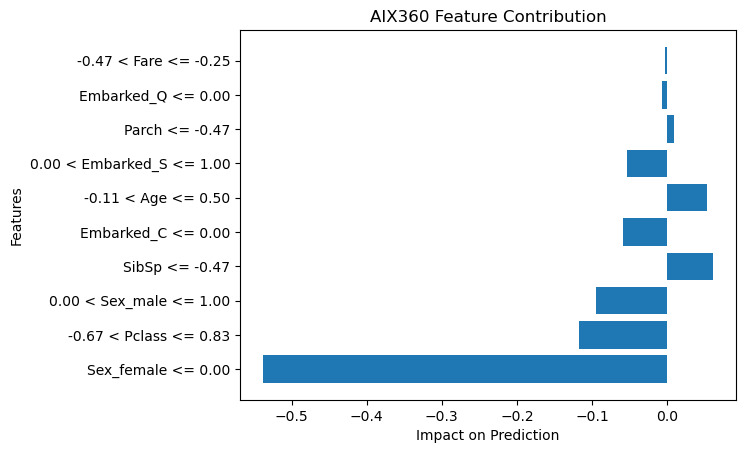

In [12]:
import matplotlib.pyplot as plt

# Get explanation list
exp_list = aix_exp.as_list()

features = [x[0] for x in exp_list]
weights = [x[1] for x in exp_list]

plt.figure()
plt.barh(features, weights)
plt.title("AIX360 Feature Contribution")
plt.xlabel("Impact on Prediction")
plt.ylabel("Features")
plt.show()

In [16]:
pip install alibi

  Using cached alibi-0.9.6-py3-none-any.whl.metadata (22 kB)
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [21 lines of output]
  + C:\Users\Neha\anaconda3\python.exe C:\Users\Neha\AppData\Local\Temp\pip-install-7ohljkkx\numpy_05f4c45e8d5c4568be537c10ba0ed344\vendored-meson\meson\meson.py setup C:\Users\Neha\AppData\Local\Temp\pip-install-7ohljkkx\numpy_05f4c45e8d5c4568be537c10ba0ed344 C:\Users\Neha\AppData\Local\Temp\pip-install-7ohljkkx\numpy_05f4c45e8d5c4568be537c10ba0ed344\.mesonpy-r6uajkr7 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\Neha\AppData\Local\Temp\pip-install-7ohljkkx\numpy_05f4c45e8d5c4568be537c10ba0ed344\.mesonpy-r6uajkr7\meson-python-native-file.ini
  The Meson build system
  Version: 1.2.99
  Source dir: C:\Users\Neha\AppData\Local\Temp\pip-install-7ohljkkx\numpy_05f4c45e8d5c4568be537c10ba0ed344
  Build dir: C:\Users\Neha\AppData\Local\Temp\pip-install-7ohljkkx\numpy_05f4c45e8d5c4568be537c10ba0ed344\.mesonpy-r6uajkr7

In [15]:
from alibi.explainers import AnchorTabular, KernelShap

print("\n5. ALIBI explanation...")

try:
    background = X_train.sample(100)
    background_processed = preprocessor.transform(background)

    if hasattr(background_processed, "toarray"):
        background_processed = background_processed.toarray()

    # ---- Anchor Explainer ----
    anchor_explainer = AnchorTabular(
        predictor=model.predict,
        feature_names=all_feature_names
    )

    anchor_explainer.fit(background_processed)

    anchor_exp = anchor_explainer.explain(test_processed[0])
    print("Anchor explanation:", anchor_exp.anchor)

    # ---- Kernel SHAP (Alibi version) ----
    def predict_fn(x):
        return model.predict_proba(x)

    ks = KernelShap(predict_fn)
    ks.fit(background_processed)

    ks_exp = ks.explain(test_processed[0].reshape(1, -1))
    print("Kernel SHAP explanation generated!")

except Exception as e:
    print("ALIBI failed:", e)

ModuleNotFoundError: No module named 'alibi'